# ==========================================
# IMPORTING REQUIRED LIBRARIES
# ==========================================

In [180]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [181]:
k_values = [5, 20, 50, 100]

# ==========================================
# IMAGE LOADING AND PREPROCESSING
# ==========================================

(512, 512)
(512, 512)


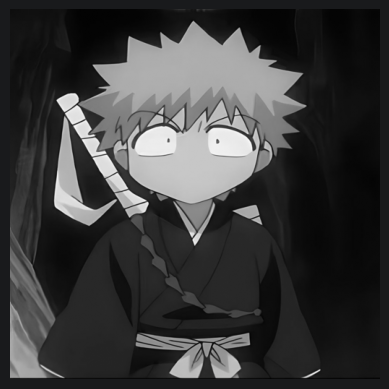

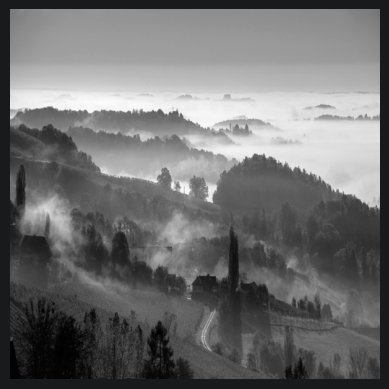

In [182]:
#loading the images
img1 = Image.open("Images/image1.jpg").convert("L")
img2 = Image.open("Images/image2.jpg").convert("L")
#resizing the images for fair comparison
img1 = img1.resize((512, 512))
img2 = img2.resize((512, 512))
#Converting to Matrix
A1 = np.array(img1)
A2 = np.array(img2)

print(A1.shape)
print(A2.shape)
#Displaying the images
plt.imshow(A1, cmap='gray')
plt.axis('off')
plt.show()

plt.imshow(A2, cmap='gray')
plt.axis('off')
plt.show()

# ==========================================
# SINGULAR VALUE DECOMPOSITION (SVD)
# ==========================================
## Singular Value Decomposition

SVD decomposes an image matrix A into:

A = UΣVᵀ

The largest singular values contain the most important information in the image.

In [183]:
#SVD computation for image1
U1, S1, VT1 = np.linalg.svd(A1, full_matrices=False)
print(U1.shape)
print(S1.shape)
print(VT1.shape)

(512, 512)
(512,)
(512, 512)


In [184]:
#SVD computation for image2
U2, S2, VT2 = np.linalg.svd(A2, full_matrices=False)
print(U2.shape)
print(S2.shape)
print(VT2.shape)

(512, 512)
(512,)
(512, 512)


# ==========================================
# IMAGE COMPRESSION USING RANK-k APPROXIMATION
# ==========================================
## Rank-k Approximation

To compress an image, only the first k singular values are retained.
This reduces storage requirements while preserving most visual information.

In [185]:
#Defining function for compression
def compress_image(U, S, VT, k):
    U_k = U[:, :k]
    S_k = np.diag(S[:k])
    VT_k = VT[:k, :]

    return U_k @ S_k @ VT_k

In [186]:
#Using the Function to compress the images
compressed1 = {}
compressed2 = {}

for k in k_values:
    compressed1[k] = compress_image(U1, S1, VT1, k)
    compressed2[k] = compress_image(U2, S2, VT2, k)

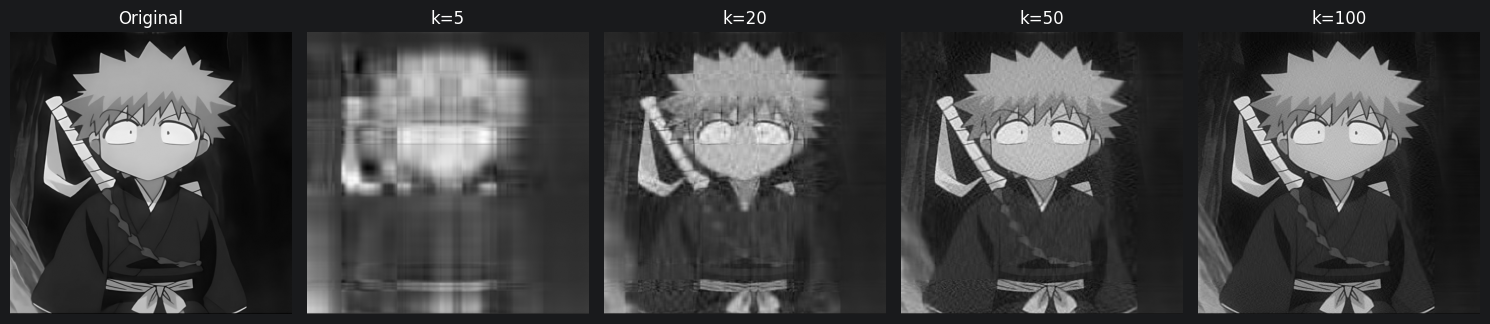

In [187]:
#Display result for img1
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

axes[0].imshow(A1, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

for i, k in enumerate(k_values):
    axes[i+1].imshow(compressed1[k], cmap='gray')
    axes[i+1].set_title(f"k={k}")
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

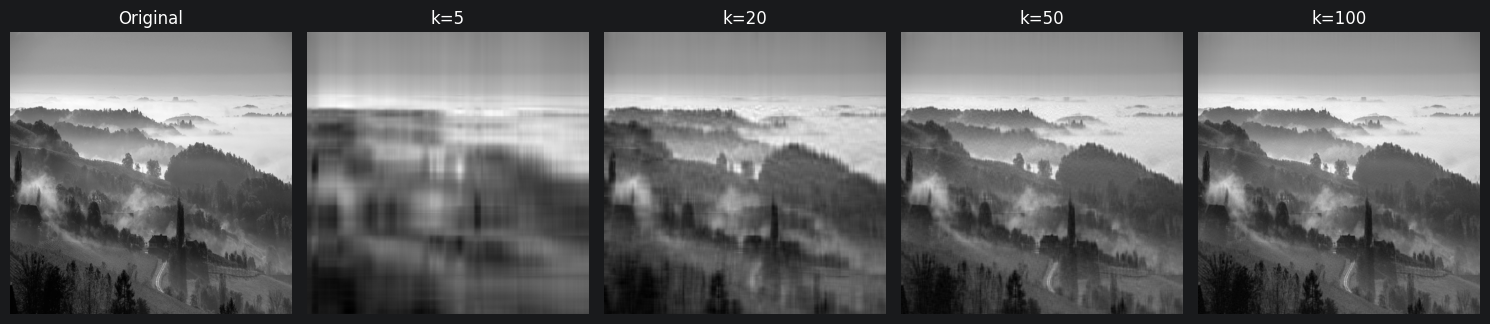

In [188]:
#Display result for img2
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

axes[0].imshow(A2, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

for i, k in enumerate(k_values):
    axes[i+1].imshow(compressed2[k], cmap='gray')
    axes[i+1].set_title(f"k={k}")
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

# ==========================================
# NUMERICAL ANALYSIS
# ==========================================
## Numerical Metrics

The following metrics are used:

- Energy Retained
- Reconstruction Error
- Storage Requirement
- Compression Ratio
- Percentage of Singular Values Used

In [189]:
#Defining function to calculate energy retained
def energy_retained(S, k):
    return np.sum(S[:k]**2) / np.sum(S**2)

In [190]:
#Energy retained in img1
for k in k_values:
    print(k, energy_retained(S1, k))

5 0.9114562230833548
20 0.9704784087523577
50 0.9894355450653715
100 0.9970454955053206


In [191]:
#Energy retained in img2
for k in k_values:
    print(k, energy_retained(S2, k))

5 0.9859069485760081
20 0.9964163006227801
50 0.9987627340940052
100 0.9995439999731733


In [192]:
#Defining Function for calculating reconstruction error
def reconstruction_error(original, reconstructed):
    return np.linalg.norm(original - reconstructed, 'fro') / np.linalg.norm(original, 'fro')

In [193]:
#Reconstruction error in img1
for k in k_values:
    err = reconstruction_error(A1, compressed1[k])
    print(k, err)

5 0.29756306376404534
20 0.17181848342841965
50 0.10278353435559864
100 0.054355353873186116


In [194]:
#Reconstruction error in img2
for k in k_values:
    err = reconstruction_error(A2, compressed2[k])
    print(k, err)

5 0.11871415848158963
20 0.0598640073601828
50 0.03517479077400448
100 0.02135415713220044


In [195]:
#Creating a table for results of img1
results = []
m, n = A1.shape
for k in k_values:
    storage = k * (m + n + 1)
    compression_ratio = (m * n) / storage
    rank = len(S1)
    percentage_sv = (k / rank) * 100
    compression_percentage = (1 - storage/(m*n))*100
    results.append({
        "k": k,
        "Energy Retained": energy_retained(S1, k),
        "Reconstruction Error": reconstruction_error(A1, compressed1[k]),
        "Storage": storage,
        "Compression Ratio": compression_ratio,
        "Rank": rank,
        "Percentage SV": percentage_sv,
        "Compression Percentage": compression_percentage
    })
df1 = pd.DataFrame(results)
df1

,k,Energy Retained,Reconstruction Error,Storage,Compression Ratio,Rank,Percentage SV,Compression Percentage
0,5,0.911456,0.297563,5125,51.150049,512,0.976562,98.044968
1,20,0.970478,0.171818,20500,12.787512,512,3.906250,92.179871
2,50,0.989436,0.102784,51250,5.115005,512,9.765625,80.449677
3,100,0.997045,0.054355,102500,2.557502,512,19.531250,60.899353


In [196]:
#Creating a table for results of img2
results = []
m, n = A2.shape
for k in k_values:
    storage = k * (m + n + 1)
    compression_ratio = (m * n) / storage
    rank = len(S2)
    percentage_sv = (k / rank) * 100
    compression_percentage = (1 - storage/(m*n))*100
    results.append({
        "k": k,
        "Energy Retained": energy_retained(S2, k),
        "Reconstruction Error": reconstruction_error(A2, compressed2[k]),
        "Storage": storage,
        "Compression Ratio": compression_ratio,
        "Rank": rank,
        "Percentage SV": percentage_sv,
        "Compression Percentage": compression_percentage
    })
df2 = pd.DataFrame(results)
df2

,k,Energy Retained,Reconstruction Error,Storage,Compression Ratio,Rank,Percentage SV,Compression Percentage
0,5,0.985907,0.118714,5125,51.150049,512,0.976562,98.044968
1,20,0.996416,0.059864,20500,12.787512,512,3.906250,92.179871
2,50,0.998763,0.035175,51250,5.115005,512,9.765625,80.449677
3,100,0.999544,0.021354,102500,2.557502,512,19.531250,60.899353


# ==========================================
# VISUAL ANALYSIS
# ==========================================

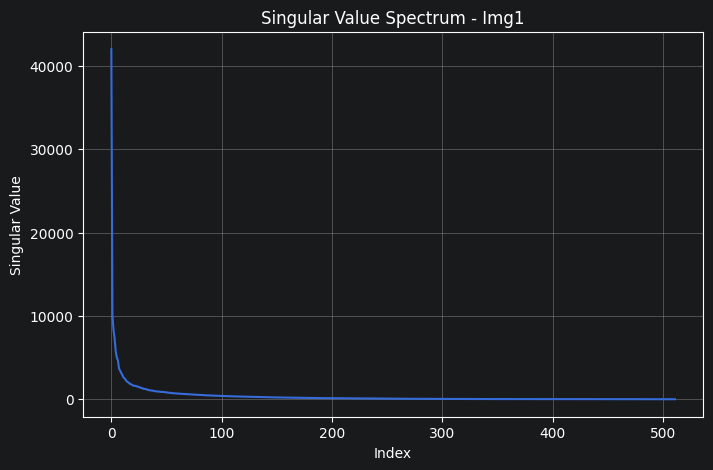

In [197]:
#Singular Value Spectrum for img1
plt.figure(figsize=(8,5))
plt.plot(S1)
plt.title("Singular Value Spectrum - Img1")
plt.xlabel("Index")
plt.ylabel("Singular Value")
plt.grid()
plt.savefig("results/singular_values_img1.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

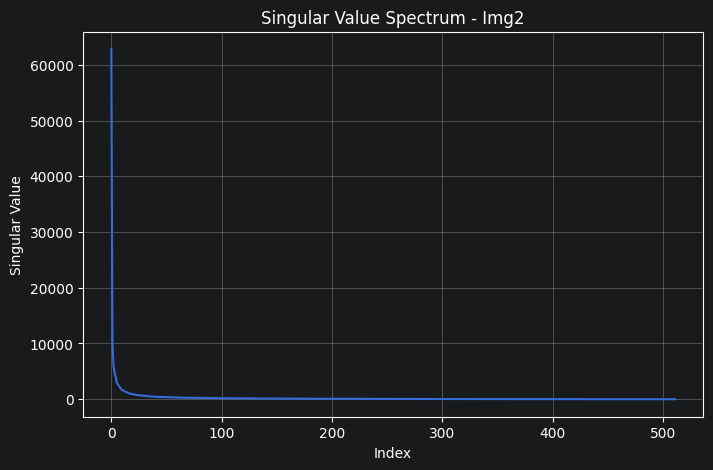

In [198]:
#Singular Value Spectrum for img2
plt.figure(figsize=(8,5))
plt.plot(S2)
plt.title("Singular Value Spectrum - Img2")
plt.xlabel("Index")
plt.ylabel("Singular Value")
plt.grid()
plt.savefig("results/singular_values_img2.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

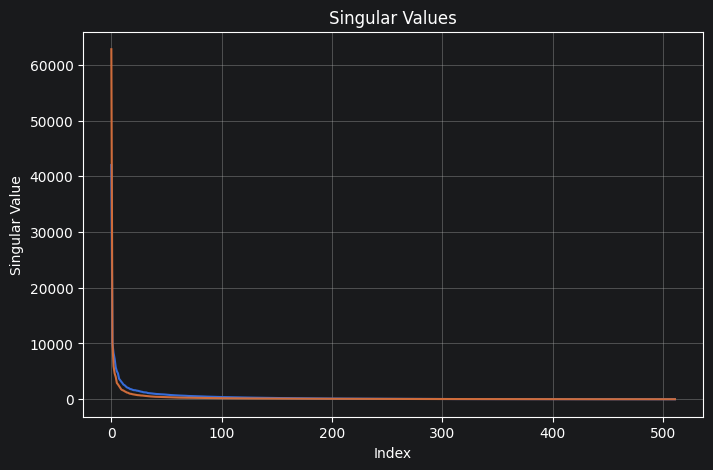

In [199]:
#Comparing singular value spectrum for both imgs
plt.figure(figsize=(8,5))
plt.plot(S1)
plt.plot(S2)
plt.title("Singular Values")
plt.xlabel("Index")
plt.ylabel("Singular Value")
plt.grid(True)
plt.savefig("results/singular_values_comparison.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

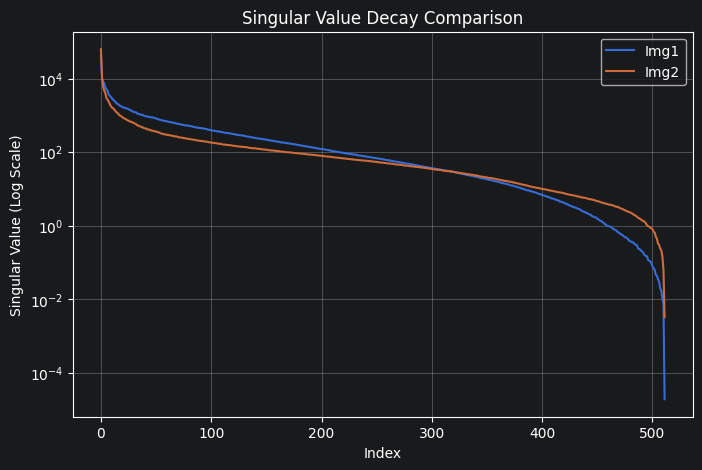

In [200]:
plt.figure(figsize=(8,5))
plt.semilogy(S1, label='Img1')
plt.semilogy(S2, label='Img2')
plt.xlabel('Index')
plt.ylabel('Singular Value (Log Scale)')
plt.title('Singular Value Decay Comparison')
plt.legend()
plt.grid()
plt.savefig("results/singular_values_log_comparison.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

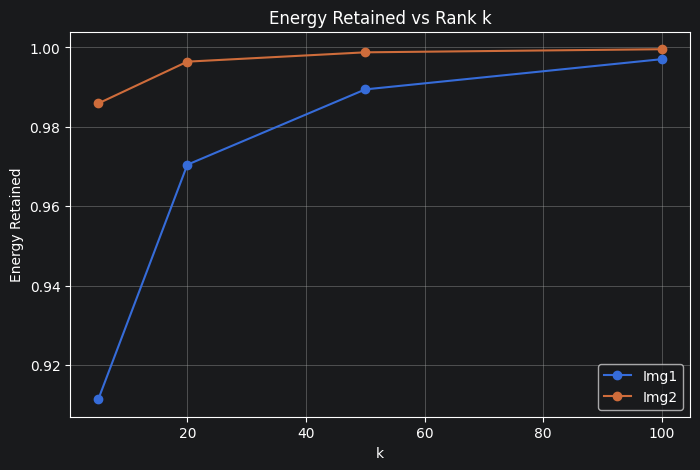

In [201]:
#Plotting Energy retained in img1 and img2
energy1 = [energy_retained(S1,k) for k in k_values]
energy2 = [energy_retained(S2,k) for k in k_values]

plt.figure(figsize=(8,5))
plt.plot(k_values, energy1, marker='o', label='Img1')
plt.plot(k_values, energy2, marker='o', label='Img2')
plt.xlabel('k')
plt.ylabel('Energy Retained')
plt.title('Energy Retained vs Rank k')
plt.legend()
plt.grid()
plt.savefig("results/Energy_retained.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

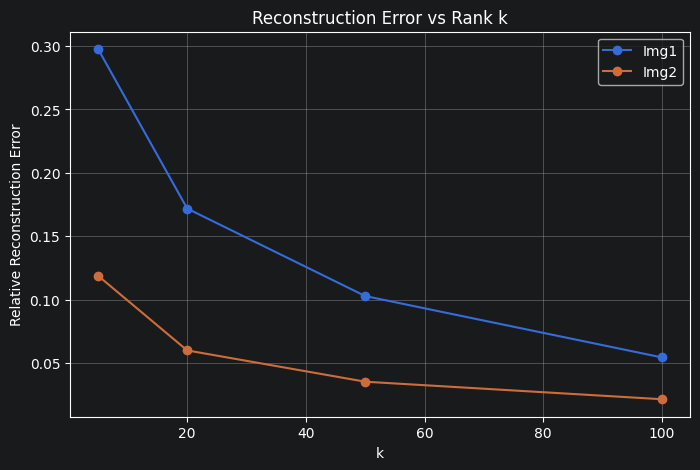

In [202]:
#Plotting Reconstruction error in img1 and img2
error1 = [reconstruction_error(A1, compressed1[k]) for k in k_values]
error2 = [reconstruction_error(A2, compressed2[k]) for k in k_values]

plt.figure(figsize=(8,5))
plt.plot(k_values, error1, marker='o', label='Img1')
plt.plot(k_values, error2, marker='o', label='Img2')
plt.xlabel('k')
plt.ylabel('Relative Reconstruction Error')
plt.title('Reconstruction Error vs Rank k')
plt.legend()
plt.grid()
plt.savefig("results/Reconstruction.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

## Key Observations

1. The image-1 retains visual quality at lower ranks.
2. The image-2 requires higher ranks.
3. Singular values decay faster for the anime image.
4. Reconstruction error decreases as k increases.
5. Energy retained increases as k increases.